In [ ]:
import os
import librosa
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from scipy.fft import dct

def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=16000, mono=True)
        if len(audio) == 0:
            return None
            
        max_peak = np.max(np.abs(audio))
        if max_peak > 0:
            audio = audio / max_peak

        # MFCCs mean + std (80 values)
        mfccs      = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfccs_mean = np.mean(mfccs, axis=1)
        mfccs_std  = np.std(mfccs, axis=1)

        # Delta MFCCs (40 values)
        delta_mfccs = librosa.feature.delta(mfccs)
        delta_mean  = np.mean(delta_mfccs, axis=1)

        # Delta-Delta MFCCs (40 values) ← NEW
        
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        delta2_mean  = np.mean(delta2_mfccs, axis=1)

        # LFCC (40 values)
        n_fft       = 512
        D           = np.abs(librosa.stft(audio, n_fft=n_fft))
        n_bins      = D.shape[0]
        n_filters   = 40
        freq_points = np.linspace(0, n_bins - 1, n_filters + 2, dtype=int)
        filters     = np.zeros((n_filters, n_bins))
        for i in range(n_filters):
            start = freq_points[i]
            mid   = freq_points[i + 1]
            end   = freq_points[i + 2]
            if mid - start > 0:
                filters[i, start:mid] = np.linspace(0, 1, mid - start)
            if end - mid > 0:
                filters[i, mid:end]   = np.linspace(1, 0, end - mid)
        filter_energies = np.dot(filters, D)
        filter_energies = np.where(filter_energies == 0,
                                   np.finfo(float).eps,
                                   filter_energies)
        lfcc_matrix = dct(np.log(filter_energies), axis=0, norm='ortho')[:40]
        lfcc_mean   = np.mean(lfcc_matrix, axis=1)

        # Chroma (12 values)
        chroma      = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)

        # Spectral Contrast (7 values)
        contrast      = librosa.feature.spectral_contrast(y=audio, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)

        # Scalar features (6 values)
        zcr_mean      = np.mean(librosa.feature.zero_crossing_rate(audio))
        zcr_std       = np.std(librosa.feature.zero_crossing_rate(audio))
        rms_mean      = np.mean(librosa.feature.rms(y=audio))
        rms_std       = np.std(librosa.feature.rms(y=audio))
        rolloff_mean  = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
        centroid_mean = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

        # Total = 40+40+40+40+40+12+7+6 = 225 features
        combined = np.hstack([
            mfccs_mean, mfccs_std, delta_mean, delta2_mean,
            lfcc_mean, chroma_mean, contrast_mean,
            [zcr_mean, zcr_std, rms_mean,
             rms_std, rolloff_mean, centroid_mean]
        ])
        return combined

    except Exception as e:
        return None


def augment_audio(audio, sr):
    """
    Creates variations of audio to help model generalize.
    We only augment FAKE samples to make them more diverse.
    """
    augmented = []

    # Add tiny background noise
    noise = np.random.randn(len(audio)) * 0.003
    augmented.append(audio + noise)

    #Slight pitch shift
    augmented.append(librosa.effects.pitch_shift(
        audio, sr=sr, n_steps=1.0))

    #  Slight time stretch
    augmented.append(librosa.effects.time_stretch(
        audio, rate=1.1))

    return augmented


def build_dataset(folders_and_labels, max_files_per_folder=2000):
    X_data = []
    y_data = []

    for folder, label in folders_and_labels:
        if not os.path.exists(folder):
            print(f" Not found: {folder}")
            continue

        files = [f for f in os.listdir(folder)
                 if f.endswith('.wav')][:max_files_per_folder]
        print(f" {folder} → {len(files)} files")

        for i, f in enumerate(files):
            file_path = os.path.join(folder, f)
            feat = extract_features(file_path)
            if feat is not None:
                X_data.append(feat)
                y_data.append(label)

                # Augment FAKE samples only
                # This makes model learn general fakeness patterns
                if label == 1:
                    try:
                        audio, sr = librosa.load(
                            file_path, sr=16000, mono=True)
                        max_peak = np.max(np.abs(audio))
                        if max_peak > 0:
                            audio = audio / max_peak
                        for aug_audio in augment_audio(audio, sr):
                            # Temporarily save augmented version
                            aug_feat = extract_features_from_array(
                                aug_audio, sr)
                            if aug_feat is not None:
                                X_data.append(aug_feat)
                                y_data.append(label)
                    except:
                        pass

            if (i + 1) % 500 == 0:
                print(f"   ✅ {i+1}/{len(files)} done...")

    return np.array(X_data), np.array(y_data)


def extract_features_from_array(audio, sr):
    """Same as extract_features but takes audio array directly."""
    try:
        max_peak = np.max(np.abs(audio))
        if max_peak > 0:
            audio = audio / max_peak

        mfccs        = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)
        mfccs_mean   = np.mean(mfccs, axis=1)
        mfccs_std    = np.std(mfccs, axis=1)
        delta_mfccs  = librosa.feature.delta(mfccs)
        delta_mean   = np.mean(delta_mfccs, axis=1)
        delta2_mfccs = librosa.feature.delta(mfccs, order=2)
        delta2_mean  = np.mean(delta2_mfccs, axis=1)

        n_fft       = 512
        D           = np.abs(librosa.stft(audio, n_fft=n_fft))
        n_bins      = D.shape[0]
        n_filters   = 40
        freq_points = np.linspace(0, n_bins-1, n_filters+2, dtype=int)
        filters     = np.zeros((n_filters, n_bins))
        for i in range(n_filters):
            start = freq_points[i]
            mid   = freq_points[i+1]
            end   = freq_points[i+2]
            if mid-start > 0:
                filters[i, start:mid] = np.linspace(0, 1, mid-start)
            if end-mid > 0:
                filters[i, mid:end]   = np.linspace(1, 0, end-mid)
        filter_energies = np.dot(filters, D)
        filter_energies = np.where(filter_energies == 0,
                                   np.finfo(float).eps,
                                   filter_energies)
        lfcc_matrix = dct(np.log(filter_energies), axis=0, norm='ortho')[:40]
        lfcc_mean   = np.mean(lfcc_matrix, axis=1)

        chroma        = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean   = np.mean(chroma, axis=1)
        contrast      = librosa.feature.spectral_contrast(y=audio, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)

        zcr_mean      = np.mean(librosa.feature.zero_crossing_rate(audio))
        zcr_std       = np.std(librosa.feature.zero_crossing_rate(audio))
        rms_mean      = np.mean(librosa.feature.rms(y=audio))
        rms_std       = np.std(librosa.feature.rms(y=audio))
        rolloff_mean  = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr))
        centroid_mean = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr))

        return np.hstack([
            mfccs_mean, mfccs_std, delta_mean, delta2_mean,
            lfcc_mean, chroma_mean, contrast_mean,
            [zcr_mean, zcr_std, rms_mean,
             rms_std, rolloff_mean, centroid_mean]
        ])
    except:
        return None




In [ ]:
#TRAINING ONLY - SKIP THIS IF THE MODEL IS TRAINED 
print("Testing on single file...")
test_file = None
for f in os.listdir("data/train/real"):
    if f.endswith('.wav'):
        test_file = os.path.join("data/train/real", f)
        break

result = extract_features(test_file)
if result is not None:
    print(f"✅ Single file test passed! Shape: {result.shape}")

    folders_and_labels = [
        ("data/train/real", 0),
        ("data/train/fake", 1),
        ("data/val/real",   0),
        ("data/val/fake",   1),
    ]

    # 1000 per folder (augmentation will 4x fake samples)
    # Total estimate: ~16000 samples, ~25 minutes
    print("\n Building augmented dataset...")
    print("   Fake samples will be augmented 3x for better generalization")
    X, y = build_dataset(folders_and_labels, max_files_per_folder=1000)

    print(f"\n Feature matrix shape: {X.shape}")
    print(f"   Real samples: {np.sum(y==0)}")
    print(f"   Fake samples: {np.sum(y==1)}")
else:
    print("❌ Failed!")

In [1]:
import joblib

# Load the already trained model — no retraining needed
pipeline = joblib.load("models/deepfake_audio_model.pkl")
print("✅ Model loaded from disk")
print("   No retraining needed — use this pipeline directly")

✅ Model loaded from disk
   No retraining needed — use this pipeline directly


In [ ]:
#skip this cell , this was used to train the model , which is trained and saved in models/deepfake_audio_model.pkl
#if runned again then it trains the model again and changes the report output by some values 
import joblib
import numpy as np
import os
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

print(" Balancing dataset...")

# Separate real and fake
X_real = X[y == 0]
X_fake = X[y == 1]
y_real = y[y == 0]
y_fake = y[y == 1]

print(f"   Before balancing → Real: {len(X_real)}, Fake: {len(X_fake)}")

# Upsample real to match fake count
# This means we repeat some real samples
X_real_upsampled, y_real_upsampled = resample(
    X_real, y_real,
    replace=True,           # Allow repeating samples
    n_samples=len(X_fake),  # Match fake count
    random_state=42
)

# Combine balanced dataset
X_balanced = np.vstack([X_real_upsampled, X_fake])
y_balanced = np.hstack([y_real_upsampled, y_fake])

# Shuffle everything
shuffle_idx = np.random.permutation(len(X_balanced))
X_balanced  = X_balanced[shuffle_idx]
y_balanced  = y_balanced[shuffle_idx]

print(f"   After balancing  → Real: {np.sum(y_balanced==0)}, "
      f"Fake: {np.sum(y_balanced==1)}")
print(f"   Total samples: {X_balanced.shape}")

# ── Train MLP on balanced data ──
print("\n Building MLP pipeline...")

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        solver='adam',
        alpha=0.05,            # Higher regularization than before
        learning_rate='adaptive',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=25,
        random_state=42,
        verbose=True
    ))
])

print(" Training on balanced dataset... (3-5 minutes)\n")
pipeline.fit(X_balanced, y_balanced)

os.makedirs("models", exist_ok=True)
joblib.dump(pipeline, "models/deepfake_audio_model.pkl")
print("\n Saved to models/deepfake_audio_model.pkl")

train_preds = pipeline.predict(X_balanced)
train_acc   = np.mean(train_preds == y_balanced) * 100
print(f"\n Training Accuracy: {train_acc:.2f}%")
print(f"   Stopped at iteration: {pipeline.named_steps['model'].n_iter_}")

# Quick sanity check — how many of each class is it predicting?
unique, counts = np.unique(train_preds, return_counts=True)
print(f"\n Training predictions breakdown:")
for u, c in zip(unique, counts):
    label = "Real" if u == 0 else "Fake"
    print(f"   {label}: {c} ({c/len(train_preds)*100:.1f}%)")

 Balancing dataset...
   Before balancing → Real: 1999, Fake: 7999
   After balancing  → Real: 7999, Fake: 7999
   Total samples: (15998, 225)

 Building MLP pipeline...
 Training on balanced dataset... (3-5 minutes)

Iteration 1, loss = 0.20270684
Validation score: 0.992917
Iteration 2, loss = 0.07039236
Validation score: 0.997500
Iteration 3, loss = 0.05867660
Validation score: 0.998750
Iteration 4, loss = 0.05386457
Validation score: 0.998750
Iteration 5, loss = 0.04972618
Validation score: 0.998750
Iteration 6, loss = 0.04573361
Validation score: 0.999167
Iteration 7, loss = 0.04188649
Validation score: 0.998750
Iteration 8, loss = 0.03822139
Validation score: 0.999167
Iteration 9, loss = 0.03476939
Validation score: 0.999167
Iteration 10, loss = 0.03153260
Validation score: 0.999167
Iteration 11, loss = 0.02853525
Validation score: 0.999167
Iteration 12, loss = 0.02578251
Validation score: 0.999167
Iteration 13, loss = 0.02325977
Validation score: 0.999167
Iteration 14, loss = 0.0

✅ Model loaded from models/deepfake_audio_model.pkl
 EVALUATING ON TEST DATA
 test/real → 500 files
 test/fake → 500 files

Metric                              Score      Target
-------------------------------------------------------
Overall Accuracy                   89.70%       ≥ 80%
F1 Score                           88.72%       ≥ 80%
Equal Error Rate (EER)              7.00%       ≤ 12%
Per-Class Acc (Real)               98.40%       ≥ 75%
Per-Class Acc (Fake)               81.00%       ≥ 75%
-------------------------------------------------------

✅ VERIFICATION CHECK:
   Accuracy ≥ 80%:  ✅ PASS
   EER ≤ 12%:       ✅ PASS
   F1 ≥ 80%:        ✅ PASS
   Real Acc ≥ 75%:  ✅ PASS
   Fake Acc ≥ 75%:  ✅ PASS

 Full Classification Report:
              precision    recall  f1-score   support

     Genuine       0.84      0.98      0.91       500
    Deepfake       0.98      0.81      0.89       500

    accuracy                           0.90      1000
   macro avg       0.91      0.90 

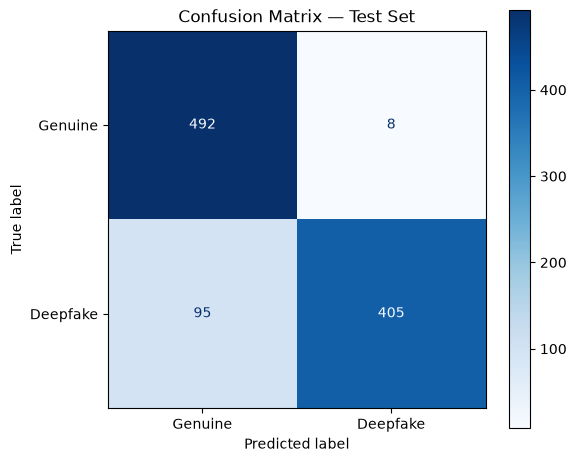

 Saved!


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (confusion_matrix, f1_score,
                             classification_report, roc_curve,
                             ConfusionMatrixDisplay)

# ── Helper functions ──
def calculate_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    frr = 1 - tpr
    idx = np.nanargmin(np.absolute(fpr - frr))
    eer = (fpr[idx] + frr[idx]) / 2
    return eer * 100

def evaluate_on_folder(split='test', max_files=500):
    X_eval = []
    y_eval = []
    categories = {'real': 0, 'fake': 1}
    for category, label in categories.items():
        folder = os.path.join("data", split, category)
        if not os.path.exists(folder):
            print(f"⚠️Not found: {folder}")
            continue
        files = [f for f in os.listdir(folder)
                 if f.endswith('.wav')][:max_files]
        print(f" {split}/{category} → {len(files)} files")
        for f in files:
            feat = extract_features(os.path.join(folder, f))
            if feat is not None:
                X_eval.append(feat)
                y_eval.append(label)
    return np.array(X_eval), np.array(y_eval)

# ── Load saved model ──
pipeline = joblib.load("models/deepfake_audio_model.pkl")
print("✅ Model loaded from models/deepfake_audio_model.pkl")
print("=" * 55)
print(" EVALUATING ON TEST DATA")
print("=" * 55)

X_test, y_test = evaluate_on_folder(split='test', max_files=500)

test_preds = pipeline.predict(X_test)
test_probs = pipeline.predict_proba(X_test)[:, 1]

test_acc = np.mean(test_preds == y_test) * 100
f1_test  = f1_score(y_test, test_preds, average='binary') * 100
eer_test = calculate_eer(y_test, test_probs)
cm_test  = confusion_matrix(y_test, test_preds)

tn, fp, fn, tp = cm_test.ravel()
real_acc = tn / (tn + fp) * 100
fake_acc = tp / (tp + fn) * 100

print(f"\n{'Metric':<30} {'Score':>10}  {'Target':>10}")
print("-" * 55)
print(f"{'Overall Accuracy':<30} {test_acc:>9.2f}%  {'≥ 80%':>10}")
print(f"{'F1 Score':<30} {f1_test:>9.2f}%  {'≥ 80%':>10}")
print(f"{'Equal Error Rate (EER)':<30} {eer_test:>9.2f}%  {'≤ 12%':>10}")
print(f"{'Per-Class Acc (Real)':<30} {real_acc:>9.2f}%  {'≥ 75%':>10}")
print(f"{'Per-Class Acc (Fake)':<30} {fake_acc:>9.2f}%  {'≥ 75%':>10}")
print("-" * 55)

print("\n✅ VERIFICATION CHECK:")
print(f"   Accuracy ≥ 80%:  {'✅ PASS' if test_acc >= 80 else '❌ FAIL'}")
print(f"   EER ≤ 12%:       {'✅ PASS' if eer_test <= 12 else '❌ FAIL'}")
print(f"   F1 ≥ 80%:        {'✅ PASS' if f1_test >= 80 else '❌ FAIL'}")
print(f"   Real Acc ≥ 75%:  {'✅ PASS' if real_acc >= 75 else '❌ FAIL'}")
print(f"   Fake Acc ≥ 75%:  {'✅ PASS' if fake_acc >= 75 else '❌ FAIL'}")

print("\n Full Classification Report:")
print(classification_report(y_test, test_preds,
                            target_names=["Genuine", "Deepfake"]))

# Predictions breakdown on test
unique, counts = np.unique(test_preds, return_counts=True)
print(f"\n Test predictions breakdown:")
for u, c in zip(unique, counts):
    label = "Real" if u == 0 else "Fake"
    print(f"   {label}: {c} ({c/len(test_preds)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                               display_labels=["Genuine", "Deepfake"])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/confusion_matrix_test.png", dpi=150)
plt.show()
print(" Saved!")

In [49]:
print("📊 COPY THESE EXACT NUMBERS FOR THE REPORT")
print("=" * 55)
print(f"Overall Accuracy:        {test_acc:.2f}%")
print(f"F1 Score:                {f1_test:.2f}%")
print(f"Equal Error Rate (EER):  {eer_test:.2f}%")
print(f"Per-Class Acc (Real):    {real_acc:.2f}%")
print(f"Per-Class Acc (Fake):    {fake_acc:.2f}%")
print(f"\nConfusion Matrix:")
print(f"  True Real predicted Real (TN):  {tn}")
print(f"  True Real predicted Fake (FP):  {fp}")
print(f"  True Fake predicted Real (FN):  {fn}")
print(f"  True Fake predicted Fake (TP):  {tp}")
print(f"\nClassification Report:")
print(classification_report(y_test, test_preds,
                            target_names=["Genuine", "Deepfake"]))

📊 COPY THESE EXACT NUMBERS FOR THE REPORT
Overall Accuracy:        89.70%
F1 Score:                88.72%
Equal Error Rate (EER):  7.00%
Per-Class Acc (Real):    98.40%
Per-Class Acc (Fake):    81.00%

Confusion Matrix:
  True Real predicted Real (TN):  492
  True Real predicted Fake (FP):  8
  True Fake predicted Real (FN):  95
  True Fake predicted Fake (TP):  405

Classification Report:
              precision    recall  f1-score   support

     Genuine       0.84      0.98      0.91       500
    Deepfake       0.98      0.81      0.89       500

    accuracy                           0.90      1000
   macro avg       0.91      0.90      0.90      1000
weighted avg       0.91      0.90      0.90      1000

